# ERA5 Climate Data Extraction: Regional Masking

**Final Project:** Heatwave Analysis in Rio de Janeiro State

**Course:** FA25-BL-EAS-G690-29302

**Professor:** Travis Allen O'Brien

**Step:** Data Pre-processing (Spatial Extraction)  

**Author:** Rafaela Quintella Veiga

**Date:** December 2025  

---

## Overview
This notebook performs the extraction of climate variables (e.g., ERA5 Temperature at 2m) from gridded global data (ERA5 reanalysis) for specific vector geometries (Stat of Rio de Janeiro and municipalities).
The output consists of spatially averaged daily time series for each region.

Dataset for testing this notebook is available here: 
📦 https://drive.google.com/drive/folders/1r7Dlz6GORhJPpgjPVCd7h6ESw1j764av?usp=sharing

The folder contains:

The folder contains:

- **ERA5 data (NetCDF)** – Global climate reanalysis at 0.25° × 0.25° horizontal 
  resolution, daily temporal resolution, produced by ECMWF.

- **Shapefiles (BR, RJ, municipalities)** – Official IBGE-aligned administrative 
  polygons for Rio de Janeiro.

- **Example output tables** generated by this notebook.


### Workflow

This notebook follows the workflow below:

1. **Setup & Configuration:**  
   Initialize the environment, import required libraries, configure plotting settings, and define file paths for the ERA5 dataset, shapefiles, and output directory.

2. **Data Inspection (Sanity Check):**  
   Verify that the ERA5 NetCDF and shapefiles load correctly, confirm that the target variable (`t2m`) exists, check CRS consistency, and ensure the expected columns (`NM_UF`, `NM_MUN`) are available for spatial joins.

3. **State-Level Spatial Extraction:**  
   Use the custom `extract` library to mask, clip, and compute spatial averages of the ERA5 variable for the State of Rio de Janeiro, generating a state-level time series.

4. **Municipal-Level Spatial Extraction:**  
   Apply the same extraction workflow to all municipalities in Rio de Janeiro, producing one time series per municipality.

5. **Export of Processed Data:**  
   Save the extracted state and municipal datasets as structured CSV files for downstream climate analysis.

6. **Data Validation & Visualization:**  
   Compute annual mean 2-m air temperature and generate a publication-quality time-series plot comparing the state average, Rio de Janeiro, and Petrópolis to validate the extraction and illustrate long-term warming trends.


## 1. Setup & Environment  

Initialize the environment, import required libraries, configure plotting, and define all file paths.

In [19]:
import os
import sys
import warnings
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- Plotting Configuration (Academic Standard) ---
# White grid background is standard for scientific publications
sns.set_style("whitegrid") 
sns.set_context("paper", font_scale=1.2)

# High resolution settings
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

# --- Custom Library Setup ---
# Ensures Python finds 'extract.py' in the current directory
sys.path.append(os.getcwd())
import extract

print(f"✅ Environment ready. Working Directory: {os.getcwd()}")

✅ Environment ready. Working Directory: c:\Users\rafaq\EASG690\Final_Project\scripts\heatwave_analysis


In [20]:
# --- File Paths --------------------------------------------------------------
# TIP: Prefix strings with 'r' to avoid escape-character issues in Windows paths
NC_FILE_PATH = r'C:\Users\rafaq\OneDrive\Documentos\IU\Travis_project\data_Era5\dados_era5_rio_janeiro_1980_2024\tmax-rj.1940.2024.v.nc'
SHP_STATE_PATH = r'C:\Users\rafaq\OneDrive\Documentos\Tese_Brasil\municipios_RJ\RJ_UF_2024\RJ_UF_2024.shp'
SHP_MUNI_PATH = r'C:\Users\rafaq\OneDrive\Documentos\Tese_Brasil\municipios_RJ\RJ_Municipios_2024\RJ_Municipios_2024.shp'

# --- Extraction Parameters ---
VAR_NAME = 't2m'         # Target variable in NetCDF (e.g., 't2m', 'tp')
# Column names used to match the geometry files
COL_STATE_NAME = 'NM_UF' # Column name in the State shapefile (e.g., 'Rio de Janeiro')
COL_MUNI_NAME = 'NM_MUN' # Column name in the Municipality shapefile (e.g., 'Petrópolis')

# --- Output Filenames ---
OUT_STATE_CSV = "results_rj_state.csv"
OUT_MUNI_CSV = "results_rj_municipalities.csv"

# --- Output Directory ---
OUTPUT_DIR = "processed_data"

# Create output folder automatically
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📂 Output directory created: {OUTPUT_DIR}")

## 2. Data Inspection (Sanity Check)
Checking if files load correctly and confirming the variable name matches `VAR_NAME`.

In [22]:
# 1. Inspect NetCDF
print("--- 🌍 ERA5 Dataset Info ---")
try:
    ds = xr.open_dataset(NC_FILE_PATH)
    print(f"Dimensions: {ds.dims}")
    if VAR_NAME in ds.data_vars:
        print(f"✅ Variable '{VAR_NAME}' found!")
    else:
        print(f"❌ Variable '{VAR_NAME}' NOT found. Available: {list(ds.data_vars)}")
except FileNotFoundError:
    print(f"❌ Error: NetCDF file not found at {NC_FILE_PATH}")

# 2. Inspect Shapefiles
print("\n--- 🗺️ Geometries Info ---")
try:
    gdf_state = gpd.read_file(SHP_STATE_PATH)
    print(f"State Shapefile: {len(gdf_state)} region(s). CRS: {gdf_state.crs}")
    if COL_STATE_NAME not in gdf_state.columns:
        print(f"⚠️ Warning: Column '{COL_STATE_NAME}' not found in State Shapefile.")
    
    gdf_muni = gpd.read_file(SHP_MUNI_PATH)
    print(f"Municipal Shapefile: {len(gdf_muni)} region(s). CRS: {gdf_muni.crs}")
    if COL_MUNI_NAME not in gdf_muni.columns:
        print(f"⚠️ Warning: Column '{COL_MUNI_NAME}' not found in Muni Shapefile.")
        
except Exception as e:
    print(f"❌ Error reading shapefiles: {e}")

--- 🌍 ERA5 Dataset Info ---
Dimensions: FrozenMappingWarningOnValuesAccess({'time': 31014, 'latitude': 17, 'longitude': 23})
✅ Variable 't2m' found!

--- 🗺️ Geometries Info ---
State Shapefile: 1 region(s). CRS: EPSG:4674
Municipal Shapefile: 92 region(s). CRS: EPSG:4674


---
## 3. Execution: State Level Extraction
Extracting data for the State using column `{COL_STATE_NAME}`.

In [23]:
# Select the variable dynamically using your config
da_input = ds[VAR_NAME]

print(f"🚀 Starting State-level extraction for variable: {VAR_NAME}...")

df_state = extract.extract_data(
    da=da_input,
    shapefile_path=SHP_STATE_PATH,
    region_column=COL_STATE_NAME 
)

# Save result
if not df_state.empty:
    path_out = os.path.join(OUTPUT_DIR, OUT_STATE_CSV) 
    df_state.to_csv(path_out, index=False)
    print(f"✅ State data saved: {path_out}")
else:
    print("⚠️ Warning: State extraction returned empty data.")

🚀 Starting State-level extraction for variable: t2m...
=== Extracting data for each region based on column: 'NM_UF' ===


Processing regions: 100%|██████████| 1/1 [00:00<00:00,  3.14it/s]

✅ Extraction complete for 1 subregions
✅ State data saved: processed_data\results_rj_state.csv


---
## 4. Execution: Municipal Level Extraction
Extracting data for all municipalities using column `{COL_MUNI_NAME}`.

In [24]:
print(f"🚀 Starting Municipal-level extraction...")

df_muni = extract.extract_data(
    da=da_input,
    shapefile_path=SHP_MUNI_PATH,
    region_column=COL_MUNI_NAME 
)

# Save result
if not df_muni.empty:
    path_out = os.path.join(OUTPUT_DIR, OUT_MUNI_CSV) 
    df_muni.to_csv(path_out, index=False)
    print(f"✅ Municipal data saved: {path_out}")
else:
    print("⚠️ Warning: Municipal extraction returned empty data.")

🚀 Starting Municipal-level extraction...
=== Extracting data for each region based on column: 'NM_MUN' ===


Processing regions: 100%|██████████| 92/92 [00:07<00:00, 11.90it/s]


✅ Extraction complete for 92 subregions
✅ Municipal data saved: processed_data\results_rj_municipalities.csv


## 5. Export of Processed Data: 
Extraction complete. Generated files:
1.  State Data: `{OUT_STATE_CSV}`
2.  Municipal Data: `{OUT_MUNI_CSV}`

In [25]:
print("🔍 Preview of generated data:")

if 'df_state' in locals() and not df_state.empty:
    print(f"\nState Data ({OUT_STATE_CSV}):")
    display(df_state.head(3))

if 'df_muni' in locals() and not df_muni.empty:
    print(f"\nMunicipal Data ({OUT_MUNI_CSV}):")
    display(df_muni.head(3))

🔍 Preview of generated data:

State Data (results_rj_state.csv):


,time,number,t2m,year,month,day,region
0,1940-01-01,0,23.715909,1940,1,1,Rio de Janeiro
1,1940-01-02,0,26.572558,1940,1,2,Rio de Janeiro
2,1940-01-03,0,27.098070,1940,1,3,Rio de Janeiro



Municipal Data (results_rj_municipalities.csv):


,time,number,t2m,year,month,day,region
0,1940-01-01,0,23.155609,1940,1,1,Mangaratiba
1,1940-01-02,0,26.644745,1940,1,2,Mangaratiba
2,1940-01-03,0,26.664825,1940,1,3,Mangaratiba


---
## 6. Data Validation & Visualization: Annual Trends
A quick visual inspection to ensure the extracted data looks consistent. 

We will validate the data by plotting the annual mean temperature for:

- **State Average (RJ)**
- **Rio de Janeiro (Capital)**
- **Petrópolis (Mountain region)**


📊 Generating validation plot...


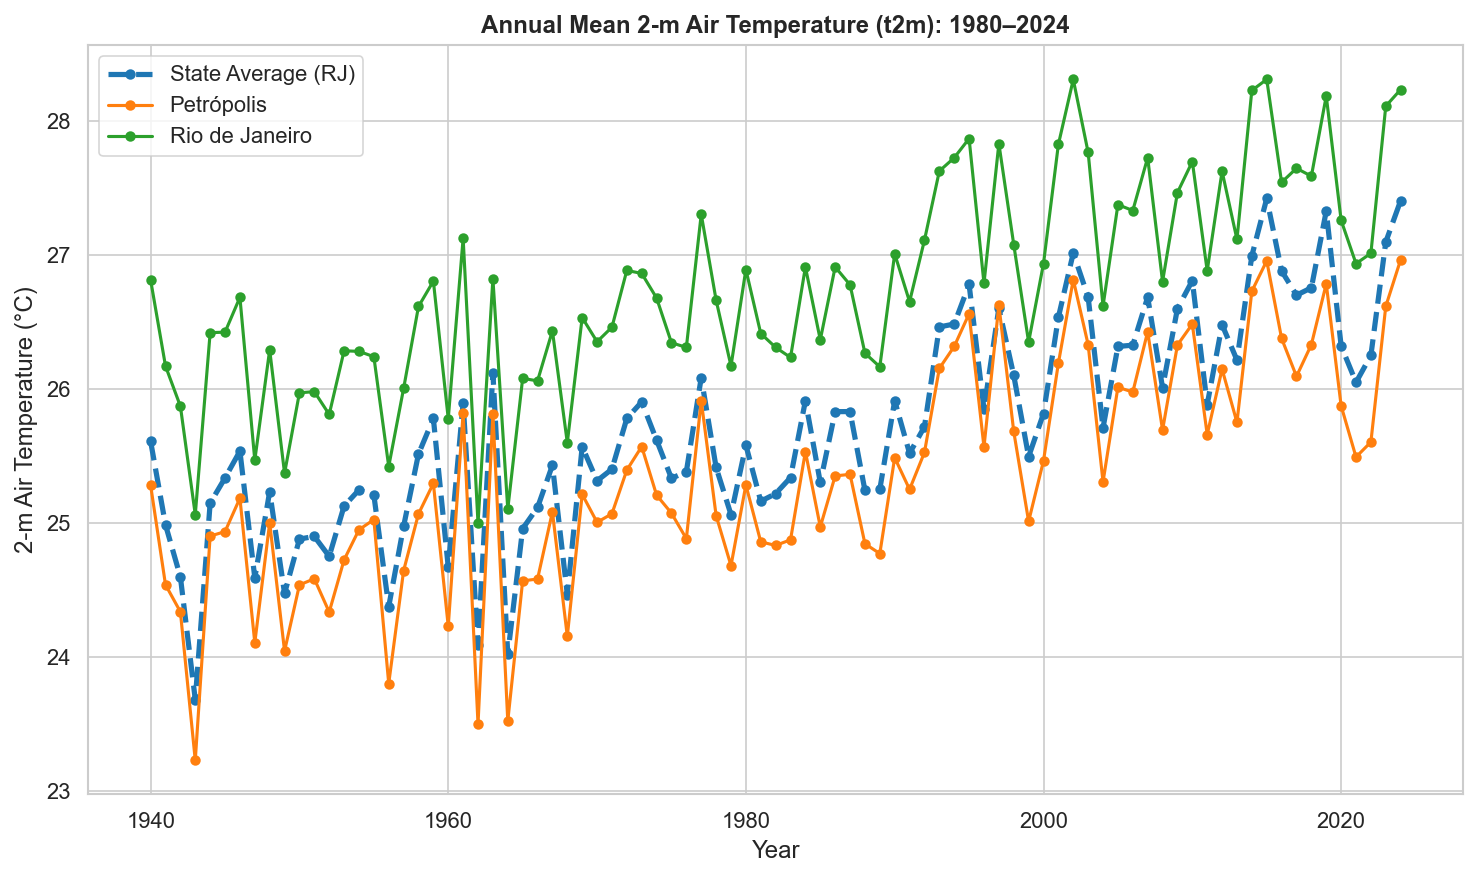

In [26]:
print("📊 Generating validation plot...")

# 1. Prepare Dates (Safety Step)
# Ensure columns are numeric before converting to datetime
for df in [df_state, df_muni]:
    if not df.empty:
        df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# 2. Select Specific Municipalities for Comparison
# TIP: Check the exact spelling in your Shapefile (e.g. 'Rio de Janeiro' vs 'RIO DE JANEIRO')
target_cities = ["Rio de Janeiro", "Petrópolis"]

# Filter checks if city exists to avoid errors
available_cities = df_muni["region"].unique()
valid_cities = [c for c in target_cities if c in available_cities]

if not valid_cities:
    print(f"⚠️ Warning: Targets {target_cities} not found in 'region' column.")
    print(f"Available regions example: {available_cities[:5]}")
    # Fallback: take the first 2 cities
    valid_cities = available_cities[:2]

df_muni_sel = df_muni[df_muni["region"].isin(valid_cities)].copy()

# 3. Calculate Annual Means
# State
annual_state = df_state.groupby("year")[VAR_NAME].mean().reset_index()
annual_state["region"] = "State Average (RJ)"

# Municipalities
annual_muni = df_muni_sel.groupby(["region", "year"])[VAR_NAME].mean().reset_index()

# Combine
annual_all = pd.concat([annual_state, annual_muni], ignore_index=True)

# 4. Plotting 
plt.figure(figsize=(10, 6))

# Loop to plot each line
for reg in annual_all["region"].unique():
    sub = annual_all[annual_all["region"] == reg]
    
    # Style logic: Make State dashed/thicker to distinguish
    linestyle = '--' if 'State' in reg else '-'
    linewidth = 2.5 if 'State' in reg else 1.5
    
    plt.plot(sub["year"], sub[VAR_NAME], 
             marker="o", markersize=4, 
             linestyle=linestyle, linewidth=linewidth, 
             label=reg)

plt.title(f"Annual Mean 2-m Air Temperature ({VAR_NAME}): 1980–2024", fontweight='bold')
plt.xlabel("Year")
plt.ylabel("2-m Air Temperature (°C)")
plt.legend(frameon=True)
plt.tight_layout()

# Save validation plot
plt.savefig(os.path.join(OUTPUT_DIR, "validation_plot.png"))
plt.show()

## Figure 1. Annual Mean 2-m Air Temperature (t2m): 1940–2024

Figure 1 shows the annual mean near-surface temperature (t2m) extracted from ERA5 for three spatial domains in the State of Rio de Janeiro:
(1) the state of Rio de Janeiro average (blue);
(2) the municipality of Petrópolis, representing a cooler mountain region (orange);
(3) the municipality of Rio de Janeiro, representing a coastal lowland urban environment (green).


The figure presents the time series of annual mean temperature from 1940 to 2024 for three areas: the State of Rio de Janeiro (state average), the municipality of Rio de Janeiro, and Petrópolis. A consistent warming trend is observed across all regions throughout the decades. While temperatures in the early part of the record (1940s–1950s) generally ranged between 24°C and 26°C, values in the later period (post-2000) become concentrated between 26°C and 28°C, indicating a clear increase in annual mean temperatures.

The municipality of Rio de Janeiro shows the highest annual mean temperatures among the three regions over the entire time series, as well as the strongest warming signal, surpassing 28°C in several years after 2000. This behavior is associated with intense urban characteristics of the capital city, including high population density, widespread impervious surfaces, and pronounced urban heat-island effects.

Petrópolis, located in a mountainous area of the Serra do Mar, exhibits lower annual mean temperatures, reflecting the influence of elevation. Nevertheless, the municipality also shows a notable warming trend, particularly after the 1990s, with an increase of approximately 2°C.

The state-level average, which aggregates data from municipalities with diverse climatic characteristics, lies between the two municipal profiles. Even so, it closely follows the warming patterns observed in Rio de Janeiro and Petrópolis, reinforcing a coherent regional trend.